In [1]:
import pandas as pd

#C:\Users\MCarrilloL\Documents\GitHub\THC\Python\BasesDeDatos

df = pd.read_csv("C:\\Users\\MCarrilloL\\Documents\\GitHub\\THC\\Python\\BasesDeDatos\\SSNMX_2010_2015.csv")          # si no hay encabezado: pd.read_csv("datos.csv", header=None, names=["x","y"])


In [2]:
df.head(10)

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Fecha UTC,Hora UTC
0,01/01/2010,03:26:56,4.1,16.01,-98.20,3.0,01/01/2010,09:26:56
1,01/01/2010,03:31:21,3.9,15.98,-98.41,6.0,01/01/2010,09:31:21
2,01/01/2010,03:36:09,3.7,16.05,-98.41,14.0,01/01/2010,09:36:09
3,01/01/2010,03:40:18,3.4,15.96,-98.31,4.0,01/01/2010,09:40:18
4,01/01/2010,03:43:14,3.8,16.01,-98.45,4.0,01/01/2010,09:43:14
5,01/01/2010,04:55:21,3.4,17.94,-98.54,58.0,01/01/2010,10:55:21
6,01/01/2010,23:22:26,4,15.89,-97.28,25.0,02/01/2010,05:22:26
7,01/01/2010,23:59:18,3.9,17.05,-94.55,189.0,02/01/2010,05:59:18
8,02/01/2010,10:09:17,4.3,13.92,-92.69,5.0,02/01/2010,16:09:17
9,02/01/2010,17:47:44,4.1,16.92,-95.52,142.0,02/01/2010,23:47:44


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36892 entries, 0 to 36891
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Fecha        36892 non-null  object 
 1   Hora         36892 non-null  object 
 2   Magnitud     36892 non-null  object 
 3   Latitud      36892 non-null  float64
 4   Longitud     36892 non-null  float64
 5   Profundidad  36892 non-null  float64
 6   Fecha UTC    36892 non-null  object 
 7   Hora UTC     36892 non-null  object 
dtypes: float64(3), object(5)
memory usage: 2.3+ MB


In [4]:
df.describe()

,Latitud,Longitud,Profundidad
count,36892.000000,36892.000000,36892.000000
mean,18.050185,-98.969606,33.606996
std,4.916731,6.453819,38.775523
min,11.752000,-120.595000,0.000000
25%,15.370000,-101.090000,10.000000
50%,16.331500,-98.141400,16.100000
75%,17.840000,-93.684600,44.725000
max,33.466500,-85.546700,338.000000


In [8]:
df['Magnitud'] = pd.to_numeric(df['Magnitud'], errors='coerce')
print(df['Magnitud'].dtype)
print(df.describe())

float64
           Magnitud       Latitud      Longitud   Profundidad
count  36889.000000  36892.000000  36892.000000  36892.000000
mean       3.691672     18.050185    -98.969606     33.606996
std        0.354608      4.916731      6.453819     38.775523
min        1.200000     11.752000   -120.595000      0.000000
25%        3.500000     15.370000   -101.090000     10.000000
50%        3.700000     16.331500    -98.141400     16.100000
75%        3.900000     17.840000    -93.684600     44.725000
max        7.500000     33.466500    -85.546700    338.000000


In [9]:
# Resumen por columna
df.isna().sum()

# Porcentaje de faltantes
(df.isna().mean() * 100).round(2)

# Filas con al menos un faltante
faltantes = df[df.isna().any(axis=1)]

In [12]:
claves = ['Fecha','Hora','Magnitud','Latitud','Longitud','Profundidad']
df_limpio = df.dropna(subset=claves)
print(df_limpio)

            Fecha      Hora  Magnitud  Latitud  Longitud  Profundidad  \
0      01/01/2010  03:26:56       4.1  16.0100  -98.2000          3.0   
1      01/01/2010  03:31:21       3.9  15.9800  -98.4100          6.0   
2      01/01/2010  03:36:09       3.7  16.0500  -98.4100         14.0   
3      01/01/2010  03:40:18       3.4  15.9600  -98.3100          4.0   
4      01/01/2010  03:43:14       3.8  16.0100  -98.4500          4.0   
...           ...       ...       ...      ...       ...          ...   
36887  31/12/2015  18:02:48       4.0  16.4748  -98.4568         30.5   
36888  31/12/2015  18:28:40       3.6  16.5262  -96.0810         29.1   
36889  31/12/2015  20:15:14       3.8  15.1860  -94.1372         15.0   
36890  31/12/2015  22:11:53       3.7  16.2205  -94.0813        111.4   
36891  31/12/2015  22:36:46       3.4  16.9475  -98.9462         41.5   

        Fecha UTC  Hora UTC  
0      01/01/2010  09:26:56  
1      01/01/2010  09:31:21  
2      01/01/2010  09:36:09  
3  

In [15]:

conteo = df['Magnitud'].value_counts().sort_index()
conteo_con_nan = df['Magnitud'].value_counts(dropna=False).sort_index()
print(conteo)


Magnitud
1.2       1
1.4       1
1.5       2
1.7       1
1.8       7
1.9      10
2.0      11
2.1      15
2.2      20
2.3      31
2.4      37
2.5      40
2.6      50
2.7      83
2.8     117
2.9     208
3.0     432
3.1     689
3.2    1097
3.3    1774
3.4    2851
3.5    4020
3.6    4880
3.7    5116
3.8    4798
3.9    3902
4.0    2816
4.1    1608
4.2     872
4.3     437
4.4     256
4.5     163
4.6     118
4.7      76
4.8      67
4.9      39
5.0      55
5.1      35
5.2      29
5.3      24
5.4      15
5.5      19
5.6      16
5.7       6
5.8       6
5.9       4
6.0       8
6.1       7
6.2       4
6.3       1
6.4       3
6.5       3
6.6       2
6.7       1
6.8       1
6.9       1
7.2       2
7.3       1
7.5       1
Name: count, dtype: int64


In [16]:
bins = [0, 2, 3, 4, 5, 6, 7, 10]   # ajusta a tu rango
conteo_bins = pd.cut(df['Magnitud'], bins=bins, right=False).value_counts().sort_index()


In [17]:
frecuencia = df['Magnitud'].round(1).value_counts().sort_index()
porcentaje = df['Magnitud'].round(1).value_counts(normalize=True).mul(100).round(2).sort_index()
tabla = pd.DataFrame({'frecuencia': frecuencia, 'porcentaje_%': porcentaje})
print(tabla)


          frecuencia  porcentaje_%
Magnitud                          
1.2                1          0.00
1.4                1          0.00
1.5                2          0.01
1.7                1          0.00
1.8                7          0.02
1.9               10          0.03
2.0               11          0.03
2.1               15          0.04
2.2               20          0.05
2.3               31          0.08
2.4               37          0.10
2.5               40          0.11
2.6               50          0.14
2.7               83          0.22
2.8              117          0.32
2.9              208          0.56
3.0              432          1.17
3.1              689          1.87
3.2             1097          2.97
3.3             1774          4.81
3.4             2851          7.73
3.5             4020         10.90
3.6             4880         13.23
3.7             5116         13.87
3.8             4798         13.01
3.9             3902         10.58
4.0             2816

In [19]:
top10 = df['Magnitud'].round(1).value_counts().head(10)
print(top10)

Magnitud
3.7    5116
3.6    4880
3.8    4798
3.5    4020
3.9    3902
3.4    2851
4.0    2816
3.3    1774
4.1    1608
3.2    1097
Name: count, dtype: int64


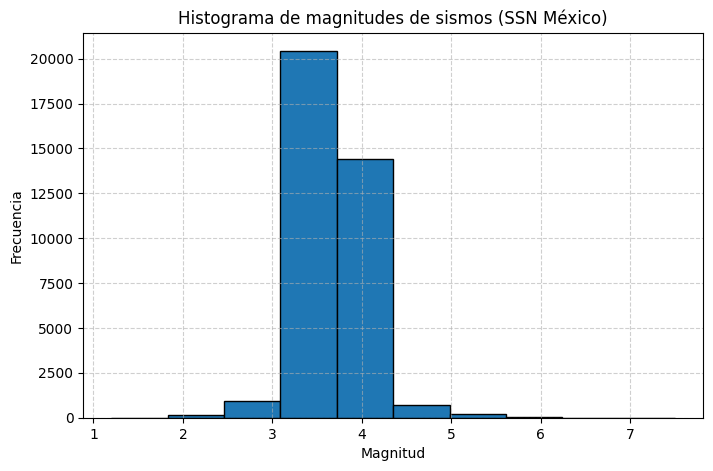

In [24]:
import matplotlib.pyplot as plt

# Asegúrate de que la columna sea numérica
df['Magnitud'] = pd.to_numeric(df['Magnitud'], errors='coerce')

# Histograma básico
df['Magnitud'].plot(kind='hist', bins=10, edgecolor='black', figsize=(8,5))
plt.xlabel('Magnitud')
plt.ylabel('Frecuencia')
plt.title('Histograma de magnitudes de sismos (SSN México)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


(array([  612., 29559.,  6452.,   209.,    31.]),
 array([2., 3., 4., 5., 6., 7.]),
 <BarContainer object of 5 artists>)

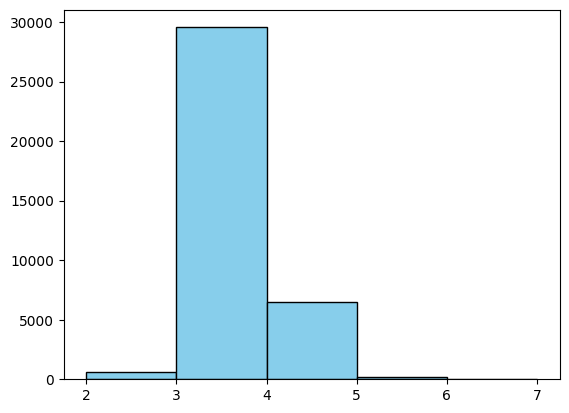

In [25]:
plt.hist(df['Magnitud'], bins=[2,3,4,5,6,7], color='skyblue', edgecolor='black')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36892 entries, 0 to 36891
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Fecha        36892 non-null  object 
 1   Hora         36892 non-null  object 
 2   Magnitud     36889 non-null  float64
 3   Latitud      36892 non-null  float64
 4   Longitud     36892 non-null  float64
 5   Profundidad  36892 non-null  float64
 6   Fecha UTC    36892 non-null  object 
 7   Hora UTC     36892 non-null  object 
dtypes: float64(4), object(4)
memory usage: 2.3+ MB


In [28]:
df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True, errors='coerce')

In [29]:
mes_nombres = {1:'Enero',2:'Febrero',3:'Marzo',4:'Abril',5:'Mayo',6:'Junio',
               7:'Julio',8:'Agosto',9:'Septiembre',10:'Octubre',11:'Noviembre',12:'Diciembre'}

conteo_mes = (
    df.groupby(df['Fecha'].dt.month)
      .size()
      .reindex(range(1,13), fill_value=0)           # asegura los 12 meses
      .rename(index=mes_nombres)
)
print(conteo_mes)


Fecha
Enero         2572
Febrero       2579
Marzo         2815
Abril         3587
Mayo          3173
Junio         2810
Julio         3163
Agosto        3087
Septiembre    3372
Octubre       3084
Noviembre     3297
Diciembre     3353
dtype: int64


In [31]:
conteo_aniomes = (
    df.set_index('Fecha')
      .resample('ME')           # frecuencia mensual calendario
      .size()
      .rename('n_eventos')
)
print(conteo_aniomes.head())


Fecha
2010-01-31    195
2010-02-28    206
2010-03-31    200
2010-04-30    559
2010-05-31    406
Freq: ME, Name: n_eventos, dtype: int64


In [32]:
df['Año'] = df['Fecha'].dt.year
df['Mes'] = df['Fecha'].dt.month
tabla_anyo_mes = pd.pivot_table(df, index='Año', columns='Mes', values='Magnitud',
                                aggfunc='count', fill_value=0)
tabla_anyo_mes = tabla_anyo_mes.rename(columns=mes_nombres)
print(tabla_anyo_mes)


Mes   Enero  Febrero  Marzo  Abril  Mayo  Junio  Julio  Agosto  Septiembre  \
Año                                                                          
2010    195      206    200    559   406    323    267     226         267   
2011    311      290    378    442   367    374    458     394         324   
2012    431      315    481    564   471    327    414     351         415   
2013    332      413    398    432   438    373    391     475         582   
2014    490      481    445    556   616    606    757     837         817   
2015    813      874    913   1034   875    807    876     804         967   

Mes   Octubre  Noviembre  Diciembre  
Año                                  
2010      288        257        268  
2011      330        315        288  
2012      442        637        395  
2013      473        490        564  
2014      632        622        748  
2015      919        973       1090  


In [33]:
# Define bins de magnitud (ajusta a tus rangos)
bins = [0, 2, 3, 4, 5, 6, 7, 10]
df['MagBin'] = pd.cut(df['Magnitud'], bins=bins, right=False)

# Conteo por mes del año y bin de magnitud
conteo_mes_mag = (df
    .groupby([df['Fecha'].dt.month, 'MagBin'])
    .size()
    .unstack(fill_value=0)
    .reindex(range(1,13))      # asegura orden de meses
    .rename(index=mes_nombres)
)
print(conteo_mes_mag)


MagBin      [0, 2)  [2, 3)  [3, 4)  [4, 5)  [5, 6)  [6, 7)  [7, 10)
Fecha                                                              
Enero            1      18    2092     445      15       1        0
Febrero          2      32    2070     460      13       2        0
Marzo            0      12    2204     572      25       1        1
Abril            1      48    2888     624      19       5        2
Mayo             2      27    2548     578      14       4        0
Junio            3     114    2173     509      10       1        0
Julio            3      49    2549     547      13       2        0
Agosto           2      69    2467     521      26       2        0
Septiembre       4      73    2650     613      29       3        0
Octubre          1      76    2455     534      15       3        0
Noviembre        2      48    2749     475      16       3        1
Diciembre        1      46    2714     574      14       4        0


C:\Users\MCarrilloL\AppData\Local\Temp\ipykernel_4856\729683038.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([df['Fecha'].dt.month, 'MagBin'])
